# 1. pretrained ResNet을 통해 food 101 분류

우선 Food-101 데이터셋을 사용할 예정

!!!!!**데이터셋크기는 약 5GB**!!!!!

## 학습없이 바로 inference

In [ ]:
import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
import os
import time
import torch.optim as optim



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치 : {device}")

batch_size = 64
num_classes = 101 #Food-101은 101개의 클래스를 가지고 있음

print("Pre-Trained ResNet-50 모델 사용")
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights = weights).to(device)
preprocess = weights.transforms() #resize, totensor, imagenet avg/std가 들어있음

val_transform = preprocess #가독성 위해서

val_dataset = torchvision.datasets.Food101(root = './data', split = 'test', download = True, transform = val_transform) #이미 여기서 모든 food101데이터는 다 다운받고 압축해제됨

val_loader = DataLoader(dataset = val_dataset,
                        batch_size = batch_size,
                        shuffle = False,
                        num_workers = 4,
                        pin_memory = True) #gpu 사용 시 데이터 전송 속도를 높임

print("pre trained resnet-50 모델을 수정..")
#각 layer의 weight와 bias텐서를 하나씩 꺼내 .requires_grad 옵션을 False로
#이 옵션은 이 파라미터와 관련된 연산은 계산 그래프에 기록하지 마라는 것임
#계산 그래프에 기록이 안되면? loss.backward()호출 후 기울기 계산을 위해서 그래프에 있는것을 확인하는데 없으니 당연히 기울기계산, 저장 생략~
for param in model.parameters():
  param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

print("="*30)
print("Baseline 성능 측정 시작!")
print("새로 붙인 Head의 가중치는 무작위 상태")

model.eval()
correct_top1 = 0
total = 0

with torch.no_grad(): #경사도 계산 비활성화 -> 메모리 사용량을 줄이고 속도 매우 빠르게 향상
  for i,(images, labels) in enumerate(val_loader): #데이터 로더에서 배치 크기만큼 빼옴
    #데이터 gpu로 이동
    images = images.to(device)
    labels = labels.to(device)

    #forward pass를 통해 모델에 이미지를 입력해 출력을 받음 -> logits값
    outputs = model(images)

    #top1
    _, predicted_top1 = torch.max(outputs.data, 1) #각 샘플마다 가장 높은 점수를 받은 클래스 찾음(최댓값 자체, 최댓값 위치한 idx) 우리는 index만 필요
    total += labels.size(0) #배치 크기를 누적합
    correct_top1 +=(predicted_top1 == labels).sum().item() #정답 맞춘 개수를 누적합 .item()을 통해 숫자로 추출

baseline_acc = 100 * correct_top1/total
print(f"Baseline Top-1 정확도 : {baseline_acc:.4f}")
print(f"101개 클래스 무작위 추측 확률 : {100/num_classes:.4f}") #학습없이 inference를 하게 되면
print("="*50)

사용 장치 : cuda
Pre-Trained ResNet-50 모델 사용
pre trained resnet-50 모델을 수정..
Baseline 성능 측정 시작!
새로 붙인 Head의 가중치는 무작위 상태
Baseline Top-1 정확도 : 0.9941
101개 클래스 무작위 추측 확률 : 0.9901


## fine-tuning(feature extraction만 사용)

In [ ]:

print("Fine-Tuning 새로운 Head만 학습")

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), #무작위로 자르고 224x224 -> 잘리면 중요한 부분도 잘려나가잖아 <- data augmentation의 일종으로 overfitting방지, 일반화 성능 높이기 위해 일부러
    transforms.RandomHorizontalFlip(), #50%확률로 좌우 반전
    transforms.ToTensor(), # [0,1] 범위 텐서로
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]) #imagenet mean, std / food-101을 학습했었던 imagenet의 mean과 std로 정규화 -> resnet의 특징 추출 능력을 100% 발휘하게
])

train_dataset = torchvision.datasets.Food101(root = './data', split = "train", download = True, transform = train_transform)

train_loader = DataLoader(dataset = train_dataset,
                         batch_size = batch_size,
                         shuffle = True,
                         num_workers = 4,
                         pin_memory = True) # num_workers는 gpu가 학습에집중 할 수 있게 cpu의 코어를 사용해서 data를 미리 준비해놓음-> 쉬지않고 훈련에 집중 가능
#큐에 미리 준비하는 batch의 개수는 prefetch_factor의 옵션에 의해서 default값은 2개 -> 총 2*4 = 8개의 batch를 준비해놓음

learning_rate = 0.005
num_epochs = 20

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr = learning_rate)#freeze되지 않은 model.fc만 학습

for epoch in range(num_epochs):
  #훈련
  print(f"epoch : {epoch+1}/{num_epochs}")

  model.train()
  running_loss = 0.0
  for i, (images, labels) in enumerate(train_loader):
    images = images.to(device)
    labels = labels.to(device)

    #forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    #backward pass
    optimizer.zero_grad() #optimizer에 연결된 모든 파라미터의 경사도 초기화
    loss.backward() #경사도가 계산되어 각 파라미터에 저장 -> 가중합으로 <- 배치크기를 메모리크기보다 크게 설정할 수 없음 -> 흉내
    optimizer.step() #위에서 계산한 경사도를 기반으로 파라미터 업데이트

    running_loss += loss.item()
    if(i+1) % 200 == 0:
      print(f"batch {i+1}/{len(train_loader)}, Train Loss : {loss.item():.4f}")

  print(f"Epoch [{epoch+1}] Train Loss : {running_loss/len(train_loader):.4f}")

  #검증
  model.eval() #dropout / batchnorm 모드 변경
  correct_top1 = 0
  total = 0
  val_loss = 0.0
  with torch.no_grad(): #일시적으로 경사도 계산 중지
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()

      _,predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct_top1 += (predicted == labels).sum().item()

  avg_val_loss = val_loss/len(val_loader) #전체 배치 수로 나눠 평균 계산 / 얼마나 심하게 틀림?
  val_acc = 100 * correct_top1 / total #몇개 맞춤?
  print(f"[fine-tuning(fc) 모델 결과] Epoch : {epoch+1} -> Val_loss : {avg_val_loss:.4f} Validation Accuracy : {val_acc:.4f}%")

print("*"*20 + "훈련 종료" +"*"*20)

Fine-Tuning 새로운 Head만 학습
epoch : 1/20
batch 200/1184, Train Loss : 2.4995
batch 400/1184, Train Loss : 2.8123
batch 600/1184, Train Loss : 2.5135
batch 800/1184, Train Loss : 2.6432
batch 1000/1184, Train Loss : 2.8262
Epoch [1] Train Loss : 2.4594
[fine-tuning(fc) 모델 결과] Epoch : 1 -> Val_loss : 1.5155 Validation Accuracy : 60.8594%
epoch : 2/20
batch 200/1184, Train Loss : 2.1139
batch 400/1184, Train Loss : 2.3332
batch 600/1184, Train Loss : 2.5047
batch 800/1184, Train Loss : 1.8703
batch 1000/1184, Train Loss : 1.8597
Epoch [2] Train Loss : 2.0778
[fine-tuning(fc) 모델 결과] Epoch : 2 -> Val_loss : 1.4717 Validation Accuracy : 62.4713%
epoch : 3/20
batch 200/1184, Train Loss : 1.6656
batch 400/1184, Train Loss : 1.7673
batch 600/1184, Train Loss : 2.4934
batch 800/1184, Train Loss : 1.9503
batch 1000/1184, Train Loss : 2.2846
Epoch [3] Train Loss : 2.0220
[fine-tuning(fc) 모델 결과] Epoch : 3 -> Val_loss : 1.5303 Validation Accuracy : 62.0713%
epoch : 4/20
batch 200/1184, Train Loss : 1.5

63프로는 조금 아쉬우니 한번 1개의 마지막 conv층도 건드려서

## fine-tuning

In [ ]:
'''
epoch, batch크기 모두 동일하게 비교
'''
for param in model.layer4.parameters(): #마지막층 unfreeze
  param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

params_to_update = [
    {
        'params':model.fc.parameters(),
        'lr' : learning_rate
    },
    { #conv층은 더 낮은 learning rate로 미세 조정
        'params':model.layer4.parameters(),
        'lr':learning_rate * 0.01
    }
]

optimizer = optim.Adam(params_to_update, lr = learning_rate) #params_to_update에 lr이 있지만 여기서 lr은 default값을 명시해주는 것

#!!!!!!위에서 썼던 코드와 동일!!!!
for epoch in range(num_epochs):
  #훈련
  print(f"epoch : {epoch+1}/{num_epochs}")

  model.train()
  running_loss = 0.0
  for i, (images, labels) in enumerate(train_loader):
    images = images.to(device)
    labels = labels.to(device)

    #forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    #backward pass
    optimizer.zero_grad() #optimizer에 연결된 모든 파라미터의 경사도 초기화
    loss.backward() #경사도가 계산되어 각 파라미터에 저장 -> 가중합으로 <- 배치크기를 메모리크기보다 크게 설정할 수 없음 -> 흉내
    optimizer.step() #위에서 계산한 경사도를 기반으로 파라미터 업데이트

    running_loss += loss.item()
    if(i+1) % 200 == 0:
      print(f"batch {i+1}/{len(train_loader)}, Train Loss : {loss.item():.4f}")

  print(f"Epoch [{epoch+1}] Train Loss : {running_loss/len(train_loader):.4f}")

  #검증
  model.eval() #dropout / batchnorm 모드 변경
  correct_top1 = 0
  total = 0
  val_loss = 0.0
  with torch.no_grad(): #일시적으로 경사도 계산 중지
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()

      _,predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct_top1 += (predicted == labels).sum().item()

  avg_val_loss = val_loss/len(val_loader) #전체 배치 수로 나눠 평균 계산 / 얼마나 심하게 틀림?
  val_acc = 100 * correct_top1 / total #몇개 맞춤?
  print(f"[fine-tuning(conv+fc) 모델 결과] Epoch : {epoch+1} -> Val_loss : {avg_val_loss:.4f} Validation Accuracy : {val_acc:.4f}%")

print("*"*20 + "훈련 종료" +"*"*20)

epoch : 1/20
batch 200/1184, Train Loss : 2.6008
batch 400/1184, Train Loss : 1.9472
batch 600/1184, Train Loss : 1.8002
batch 800/1184, Train Loss : 1.7335
batch 1000/1184, Train Loss : 1.4776
Epoch [1] Train Loss : 1.9432
[fine-tuning(conv+fc) 모델 결과] Epoch : 1 -> Val_loss : 0.9255 Validation Accuracy : 74.6614%
epoch : 2/20
batch 200/1184, Train Loss : 1.4180
batch 400/1184, Train Loss : 1.2077
batch 600/1184, Train Loss : 1.5080
batch 800/1184, Train Loss : 1.5195
batch 1000/1184, Train Loss : 0.9159
Epoch [2] Train Loss : 1.3571
[fine-tuning(conv+fc) 모델 결과] Epoch : 2 -> Val_loss : 0.7981 Validation Accuracy : 77.7307%
epoch : 3/20
batch 200/1184, Train Loss : 1.3610
batch 400/1184, Train Loss : 0.9457
batch 600/1184, Train Loss : 1.2056
batch 800/1184, Train Loss : 1.4561
batch 1000/1184, Train Loss : 1.3839
Epoch [3] Train Loss : 1.1767
[fine-tuning(conv+fc) 모델 결과] Epoch : 3 -> Val_loss : 0.7555 Validation Accuracy : 78.9347%
epoch : 4/20
batch 200/1184, Train Loss : 1.0488
batch 

10%향상

# 2. VGG16

## Feature Extraction

In [ ]:
'''
learning_rate이 중요하구나를 확실히 알게된 프로젝트가 됨

!!!!!문제!!!!!!
learning_rate가 0.005일때는 train loss도 4.중반으로 크고
validation acc 는 0.99로 매우 낮음
learning_rate을 0.0001로 낮추니 해결..
위의 resnet은 0.005로도 잘 학습했음!


!!!!!왜 이런 차이가?!!!!!
1.우선 구조적으로 Batch Normalization의 유무로 차이가..
VGG16은 BN이 내부적으로 없지만 resnet은 구조 안에 BN이 conv-bn-relu로 계속 껴있음
BN에 의해서 데이터의 분포를 강제로 평균 0 분산1로 안정화를 시키고
이로인해 학습률을 조금만 높게 잡아도 가중치가 폭발하지 않고 안정적으로 학습 <-> 없다면 가중치 값이 미친 듯이 튀어 문제가 생김

2.Skip Connection vs Series Connection
H(x) = F(x) + x로 높은 학습률로도 Global Minima를 잘 찾아갈 수 있게 해줌

3.Classifier의 무거움
resnet의 경우 가벼운 fc층 하나만 통과 -> 파라미터가 적음
VGG16의 경우 (4096, 4096)의 Linear층 2개를 통과 + VGG16은 전체 파라미터의 약 80프로 이상이 classifier에 몰려있음. 학습률이 높으면 ? 당연히 이 큰 덩어리들이 한번에 크게 움직여 모델 전체를 흔들어 버림



'''
learning_rate = 0.0001
batch_size = 32
num_epochs = 20
num_classes = 101

weights = models.VGG16_Weights.DEFAULT
model = models.vgg16(weights = weights).to(device)
preprocess = weights.transforms()

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]) #똑같이 imagenet의 mean, std
])
val_transform = preprocess

train_dataset = torchvision.datasets.Food101(root = './data', split = 'train', download = True, transform = train_transform)
val_dataset = torchvision.datasets.Food101(root = './data', split = 'test', download = True, transform = val_transform)

train_loader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True, num_workers = 4, pin_memory = True)
val_loader = DataLoader(dataset = val_dataset, batch_size = batch_size, shuffle = False, num_workers = 4, pin_memory = True)

print("Feature Extraction 시작")

for param in model.features.parameters():
  param.requires_grad = False

num_ftrs = model.classifier[0].in_features #우선 모델이 받는 feature의 개수를 저장함
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 4096),
    nn.ReLU(inplace = True),
    nn.Dropout(p = 0.5),
    nn.Linear(4096,4096),
    nn.ReLU(inplace = True),
    nn.Dropout(p = 0.5),
    nn.Linear(4096, num_classes)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.classifier.parameters(), lr = learning_rate)


#!!!!!!위에서 썼던 코드와 동일!!!!
for epoch in range(num_epochs):
  #훈련
  print(f"epoch : {epoch+1}/{num_epochs}")

  model.train()
  running_loss = 0.0
  for i, (images, labels) in enumerate(train_loader):
    images = images.to(device)
    labels = labels.to(device)

    #forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    #backward pass
    optimizer.zero_grad() #optimizer에 연결된 모든 파라미터의 경사도 초기화
    loss.backward() #경사도가 계산되어 각 파라미터에 저장 -> 가중합으로 <- 배치크기를 메모리크기보다 크게 설정할 수 없음 -> 흉내
    optimizer.step() #위에서 계산한 경사도를 기반으로 파라미터 업데이트

    running_loss += loss.item()
    if(i+1) % 200 == 0:
      print(f"batch {i+1}/{len(train_loader)}, Train Loss : {loss.item():.4f}")

  print(f"Epoch [{epoch+1}] Train Loss : {running_loss/len(train_loader):.4f}")

  #검증
  model.eval() #dropout / batchnorm 모드 변경
  correct_top1 = 0
  total = 0
  val_loss = 0.0
  with torch.no_grad(): #일시적으로 경사도 계산 중지
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()

      _,predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct_top1 += (predicted == labels).sum().item()

  avg_val_loss = val_loss/len(val_loader) #전체 배치 수로 나눠 평균 계산 / 얼마나 심하게 틀림?
  val_acc = 100 * correct_top1 / total #몇개 맞춤?
  print(f"[Feature Extraction) 모델 결과] Epoch : {epoch+1} -> Val_loss : {avg_val_loss:.4f} Validation Accuracy : {val_acc:.4f}%")

print("*"*20 + "훈련 종료" +"*"*20)

Feature Extraction 시작
epoch : 1/20
batch 200/2368, Train Loss : 4.0887
batch 400/2368, Train Loss : 2.9603
batch 600/2368, Train Loss : 2.5084
batch 800/2368, Train Loss : 3.0330
batch 1000/2368, Train Loss : 2.4183
batch 1200/2368, Train Loss : 3.1729
batch 1400/2368, Train Loss : 2.2923
batch 1600/2368, Train Loss : 1.8305
batch 1800/2368, Train Loss : 2.2658
batch 2000/2368, Train Loss : 2.6925
batch 2200/2368, Train Loss : 2.7697
Epoch [1] Train Loss : 2.8618
[Feature Extraction) 모델 결과] Epoch : 1 -> Val_loss : 1.7179 Validation Accuracy : 55.2871%
epoch : 2/20
batch 200/2368, Train Loss : 2.7376
batch 400/2368, Train Loss : 2.4292
batch 600/2368, Train Loss : 2.6267
batch 800/2368, Train Loss : 1.8668
batch 1000/2368, Train Loss : 3.0822
batch 1200/2368, Train Loss : 2.6518
batch 1400/2368, Train Loss : 2.1357
batch 1600/2368, Train Loss : 2.2277
batch 1800/2368, Train Loss : 2.2602
batch 2000/2368, Train Loss : 1.6338
batch 2200/2368, Train Loss : 2.7864
Epoch [2] Train Loss : 2.3

## fine-tuning (위의 모델을 불러와 learning_rate을 낮춰 head와 backbone을 fine tuning할 예정)

In [ ]:
'''
여기서는 위의 모델을 가져와 FC를 다시 처음부터 학습시키는것이 아니라 학습률을 더 낮춘상태에서 fine-tuning해주고
back-bone도 fine-tuning
'''

unfreeze_idx = 24 #vgg16의 특성 때문에 idx로 fine tuning할 layer를 정해야 함

for param in model.features[unfreeze_idx:].parameters():
  param.requires_grad = True

optimizer = optim.Adam([
    {
        'params' : model.classifier.parameters(),
        'lr' : 0.00001 #좀 더 낮춰 training
    },
    {
        'params' : model.features[unfreeze_idx:].parameters(),
        'lr' : 0.000005
    }
])


#!!!!!!위에서 썼던 코드와 동일!!!!
for epoch in range(num_epochs):
  #훈련
  print(f"epoch : {epoch+1}/{num_epochs}")

  model.train()
  running_loss = 0.0
  for i, (images, labels) in enumerate(train_loader):
    images = images.to(device)
    labels = labels.to(device)

    #forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    #backward pass
    optimizer.zero_grad() #optimizer에 연결된 모든 파라미터의 경사도 초기화
    loss.backward() #경사도가 계산되어 각 파라미터에 저장 -> 가중합으로 <- 배치크기를 메모리크기보다 크게 설정할 수 없음 -> 흉내
    optimizer.step() #위에서 계산한 경사도를 기반으로 파라미터 업데이트

    running_loss += loss.item()
    if(i+1) % 200 == 0:
      print(f"batch {i+1}/{len(train_loader)}, Train Loss : {loss.item():.4f}")

  print(f"Epoch [{epoch+1}] Train Loss : {running_loss/len(train_loader):.4f}")

  #검증
  model.eval() #dropout / batchnorm 모드 변경
  correct_top1 = 0
  total = 0
  val_loss = 0.0
  with torch.no_grad(): #일시적으로 경사도 계산 중지
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()

      _,predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct_top1 += (predicted == labels).sum().item()

  avg_val_loss = val_loss/len(val_loader) #전체 배치 수로 나눠 평균 계산 / 얼마나 심하게 틀림?
  val_acc = 100 * correct_top1 / total #몇개 맞춤?
  print(f"[Fine-Tuning) 모델 결과] Epoch : {epoch+1} -> Val_loss : {avg_val_loss:.4f} Validation Accuracy : {val_acc:.4f}%")

print("*"*20 + "훈련 종료" +"*"*20)

epoch : 1/20
batch 200/2368, Train Loss : 1.4913
batch 400/2368, Train Loss : 1.9705
batch 600/2368, Train Loss : 1.4480
batch 800/2368, Train Loss : 1.7862
batch 1000/2368, Train Loss : 1.9211
batch 1200/2368, Train Loss : 1.6415
batch 1400/2368, Train Loss : 1.4081
batch 1600/2368, Train Loss : 1.2491
batch 1800/2368, Train Loss : 1.5211
batch 2000/2368, Train Loss : 2.1847
batch 2200/2368, Train Loss : 1.5369
Epoch [1] Train Loss : 1.7215
[Fine-Tuning) 모델 결과] Epoch : 1 -> Val_loss : 1.2964 Validation Accuracy : 68.4792%
epoch : 2/20
batch 200/2368, Train Loss : 1.3791
batch 400/2368, Train Loss : 1.1634
batch 600/2368, Train Loss : 2.4150
batch 800/2368, Train Loss : 2.0222
batch 1000/2368, Train Loss : 1.3613
batch 1200/2368, Train Loss : 1.8163
batch 1400/2368, Train Loss : 1.5392
batch 1600/2368, Train Loss : 1.4824
batch 1800/2368, Train Loss : 1.4074
batch 2000/2368, Train Loss : 1.4674
batch 2200/2368, Train Loss : 1.1850
Epoch [2] Train Loss : 1.6414
[Fine-Tuning) 모델 결과] Epoc

# 3. ResNet vs VGG16 비교하기 (W&B사용)

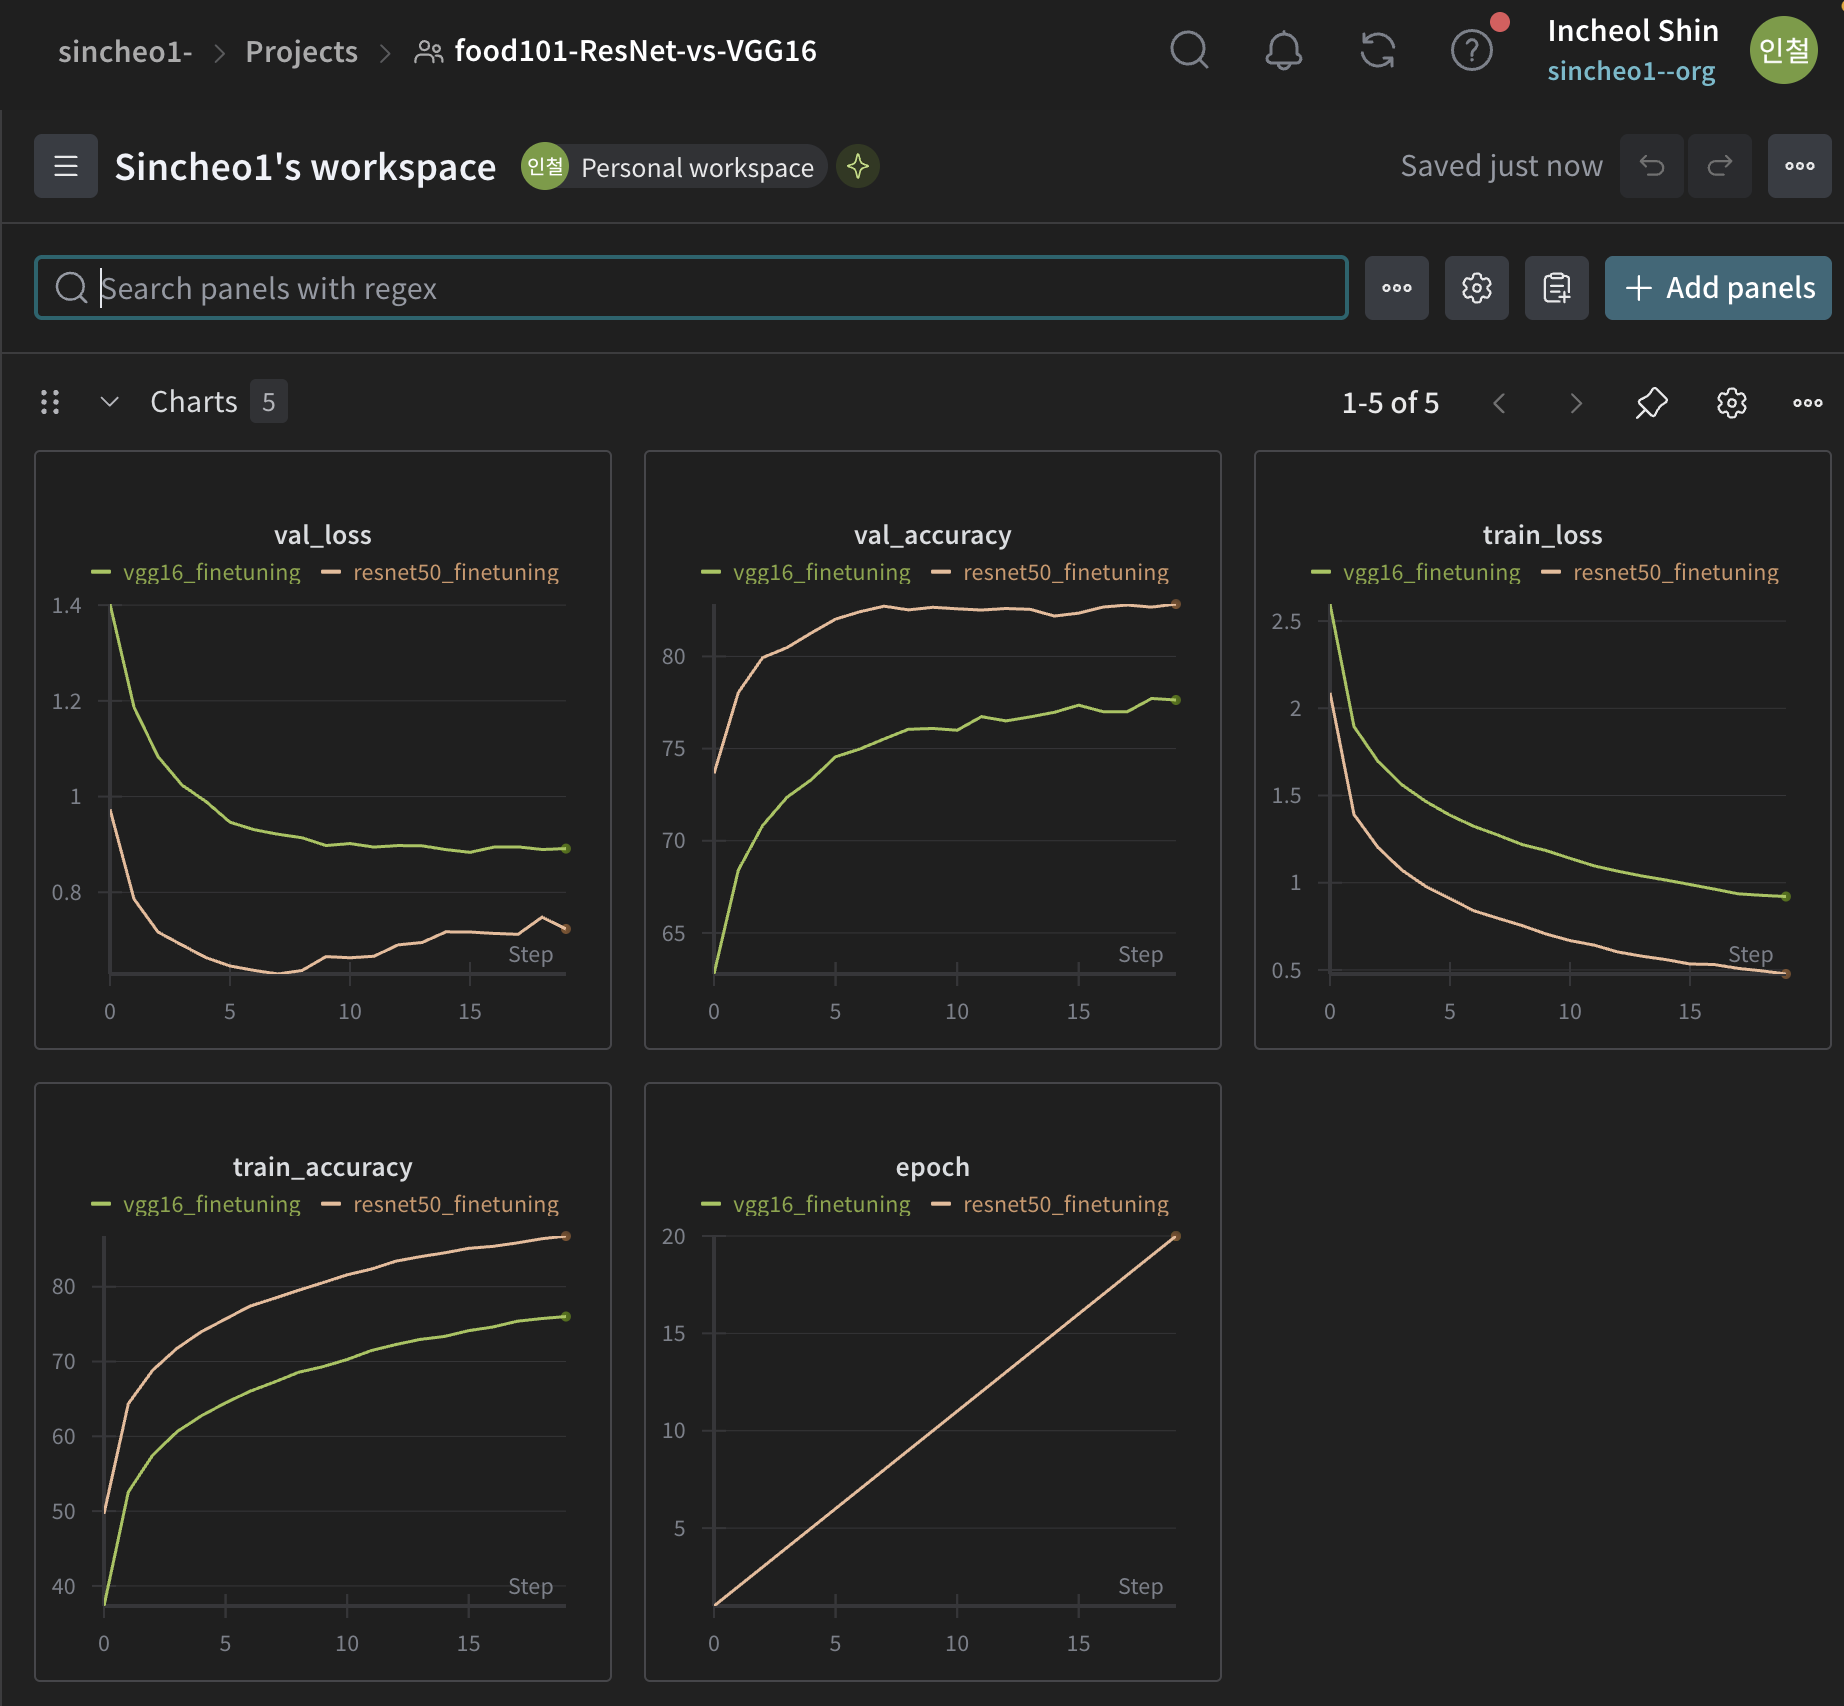

In [ ]:
!pip install wandb -1
import wandb
wandb.login(relogin=True)

import torch
import torchvision
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torch.utils.data import DataLoader


def find_model(model_name):
  params_to_update = list()

  #resnet50
  if model_name == "resnet50":
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights = weights)

    #freeze
    for param in model.parameters():
      param.requires_grad = False

    #backbone unfreeze
    for param in model.layer4.parameters(): #마지막층 unfreeze
      param.requires_grad = True

    #head교체
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    #optimizer한테 넘겨줄 학습내용
    params_to_update.extend([
        {'params' : model.layer4.parameters(),'lr' : 0.00005}, #더작게
        {'params' : model.fc.parameters(), 'lr' : 0.001} #작게
      ])

  #vgg16
  elif model_name == "vgg16":
    weights = models.VGG16_Weights.DEFAULT
    model = models.vgg16(weights = weights)

    #freeze
    for param in model.features.parameters():
      param.requires_grad = False

    #backbone unfreeze
    unfreeze_idx = 24 #vgg16의 특성 때문에 idx로 fine tuning할 layer를 정해야 함
    for param in model.features[unfreeze_idx:].parameters():
      param.requires_grad = True

    #head교체
    num_ftrs = model.classifier[0].in_features
    model.classifier = nn.Sequential(
      nn.Linear(num_ftrs, 4096),
      nn.ReLU(inplace = True),
      nn.Dropout(p = 0.5),
      nn.Linear(4096,4096),
      nn.ReLU(inplace = True),
      nn.Dropout(p = 0.5),
      nn.Linear(4096, num_classes)
    ).to(device)

    #optimizer한테 넘겨줄 학습내용
    params_to_update.extend([
        {'params' : model.classifier.parameters(),'lr' : 0.00009}, #작게
        {'params' : model.features[unfreeze_idx:].parameters(), 'lr' : 0.00005} #더작게
      ])
  else:
    print("정의되지 않은 모델")
  return model.to(device), params_to_update

def train_model(model_name):
  print(f"==========={model_name} 학습 시작=============")

  wandb.init(
      project = wandb_project,
      name = f"{model_name}_finetuning",
      config = {
          "architecture" : model_name,
          "dataset" : "Food-101",
          "epochs" : num_epochs,
          "batch_size" : batch_size
      }
      )

  model, params_to_update = find_model(model_name)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(params_to_update)

  #W&B가 모델의 구조와 그라디언트를 지켜보게 함
  wandb.watch(model, log = "all")

  #train

  #!!!!!!위에서 썼던 코드와 동일!!!!
  for epoch in range(num_epochs):
    print(f"epoch : {epoch+1}/{num_epochs}")

    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    for i, (images, labels) in enumerate(train_loader):
      images = images.to(device)
      labels = labels.to(device)

      #forward pass
      outputs = model(images)
      loss = criterion(outputs, labels)

      #backward pass
      optimizer.zero_grad() #optimizer에 연결된 모든 파라미터의 경사도 초기화
      loss.backward() #경사도가 계산되어 각 파라미터에 저장 -> 가중합으로 <- 배치크기를 메모리크기보다 크게 설정할 수 없음 -> 흉내
      optimizer.step() #위에서 계산한 경사도를 기반으로 파라미터 업데이트

      train_loss += loss.item()
      _,predicted = torch.max(outputs.data, 1)
      total_train += labels.size(0)
      correct_train += (predicted == labels).sum().item()

    avg_train_loss = train_loss/len(train_loader)
    train_acc = 100*correct_train/total_train

    print(f"Epoch [{epoch+1}] Train Loss : {avg_train_loss:.4f}")

    #검증
    model.eval() #dropout / batchnorm 모드 변경
    correct_top1 = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad(): #일시적으로 경사도 계산 중지
      for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _,predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct_top1 += (predicted == labels).sum().item()

    avg_val_loss = val_loss/len(val_loader) #전체 배치 수로 나눠 평균 계산 / 얼마나 심하게 틀림?
    val_acc = 100 * correct_top1 / total #몇개 맞춤?
    print(f"[Fine-Tuning) 모델 결과] Epoch : {epoch+1} -> Val_loss : {avg_val_loss:.4f} Validation Accuracy : {val_acc:.4f}%")

    #W&B에 로그 기록
    wandb.log({
        "train_loss" : avg_train_loss,
        "train_accuracy" : train_acc,
        "val_loss" : avg_val_loss,
        "val_accuracy" : val_acc,
        "epoch" : epoch + 1
    })

  print(f"***********{model_name}훈련 종료**********")

  wandb.finish()

  del model
  torch.cuda.empty_cache()

if __name__ =="__main__":
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  print(f"사용 장치 : {device}")

  batch_size = 64
  num_epochs = 20
  num_classes = 101
  wandb_project = "food101-ResNet-vs-VGG16"

  weights = models.ResNet50_Weights.DEFAULT #Transform을 위한 weight이기 때문에 공유해도 됨
  preprocess = weights.transforms()

  train_transform = transforms.Compose([
      transforms.RandomResizedCrop(224),
      transforms.RandomHorizontalFlip(),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  ])

  train_dataset = torchvision.datasets.Food101(root = './data', split = 'train', download = True, transform = train_transform)
  val_dataset = torchvision.datasets.Food101(root = './data', split = 'test', download = True, transform = preprocess)

  train_loader = DataLoader(
      train_dataset,
      batch_size = batch_size,
      shuffle = True,
      num_workers = 4,
      pin_memory = True
      )
  val_loader = DataLoader(
      val_dataset,
      batch_size = batch_size,
      shuffle = False,
      num_workers = 4,
      pin_memory = True
      )

  m = ['resnet50','vgg16']
  for model_name in m:
    train_model(model_name)

  print("실험 종료")


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -1


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


사용 장치 : cuda
===========resnet50 학습 시작=============


epoch,▁
train_accuracy,▁
train_loss,▁
val_accuracy,▁
val_loss,▁
epoch,1
train_accuracy,49.59472
train_loss,2.08614
val_accuracy,73.89703
val_loss,0.962


epoch : 1/20
Epoch [1] Train Loss : 2.0895
[Fine-Tuning) 모델 결과] Epoch : 1 -> Val_loss : 0.9734 Validation Accuracy : 73.6475%
epoch : 2/20
Epoch [2] Train Loss : 1.3913
[Fine-Tuning) 모델 결과] Epoch : 2 -> Val_loss : 0.7860 Validation Accuracy : 78.0396%
epoch : 3/20
Epoch [3] Train Loss : 1.2023
[Fine-Tuning) 모델 결과] Epoch : 3 -> Val_loss : 0.7169 Validation Accuracy : 79.9327%
epoch : 4/20
Epoch [4] Train Loss : 1.0720
[Fine-Tuning) 모델 결과] Epoch : 4 -> Val_loss : 0.6898 Validation Accuracy : 80.4752%
epoch : 5/20
Epoch [5] Train Loss : 0.9777
[Fine-Tuning) 모델 결과] Epoch : 5 -> Val_loss : 0.6635 Validation Accuracy : 81.2713%
epoch : 6/20
Epoch [6] Train Loss : 0.9088
[Fine-Tuning) 모델 결과] Epoch : 6 -> Val_loss : 0.6461 Validation Accuracy : 82.0238%
epoch : 7/20
Epoch [7] Train Loss : 0.8390
[Fine-Tuning) 모델 결과] Epoch : 7 -> Val_loss : 0.6368 Validation Accuracy : 82.4238%
epoch : 8/20
Epoch [8] Train Loss : 0.7961
[Fine-Tuning) 모델 결과] Epoch : 8 -> Val_loss : 0.6293 Validation Accuracy : 8

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_accuracy,▁▄▅▅▆▆▆▆▇▇▇▇▇▇██████
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
val_accuracy,▁▄▆▆▇▇██████████████
val_loss,█▄▃▂▂▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃
epoch,20
train_accuracy,86.77888
train_loss,0.47674
val_accuracy,82.84356
val_loss,0.7234


===========vgg16 학습 시작=============


epoch : 1/20
Epoch [1] Train Loss : 2.5978
[Fine-Tuning) 모델 결과] Epoch : 1 -> Val_loss : 1.4023 Validation Accuracy : 62.7723%
epoch : 2/20
Epoch [2] Train Loss : 1.8954
[Fine-Tuning) 모델 결과] Epoch : 2 -> Val_loss : 1.1869 Validation Accuracy : 68.4079%
epoch : 3/20
Epoch [3] Train Loss : 1.6955
[Fine-Tuning) 모델 결과] Epoch : 3 -> Val_loss : 1.0836 Validation Accuracy : 70.8277%
epoch : 4/20
Epoch [4] Train Loss : 1.5611
[Fine-Tuning) 모델 결과] Epoch : 4 -> Val_loss : 1.0240 Validation Accuracy : 72.3564%
epoch : 5/20
Epoch [5] Train Loss : 1.4653
[Fine-Tuning) 모델 결과] Epoch : 5 -> Val_loss : 0.9895 Validation Accuracy : 73.3109%
epoch : 6/20
Epoch [6] Train Loss : 1.3867
[Fine-Tuning) 모델 결과] Epoch : 6 -> Val_loss : 0.9464 Validation Accuracy : 74.5545%
epoch : 7/20
Epoch [7] Train Loss : 1.3230
[Fine-Tuning) 모델 결과] Epoch : 7 -> Val_loss : 0.9308 Validation Accuracy : 74.9782%
epoch : 8/20
Epoch [8] Train Loss : 1.2730
[Fine-Tuning) 모델 결과] Epoch : 8 -> Val_loss : 0.9212 Validation Accuracy : 7

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_accuracy,▁▄▅▅▆▆▆▆▇▇▇▇▇▇██████
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
val_accuracy,▁▄▅▅▆▇▇▇▇▇▇█▇███████
val_loss,█▅▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
train_accuracy,76.01452
train_loss,0.9209
val_accuracy,77.63564
val_loss,0.89127


실험 종료


# 4. 하이퍼 파라미터 튜닝(ResNet50)

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import itertools
import wandb

wandb.login()

HP_GRID = {
    'learning_rate' : [0.01,0.05,0.001,0.0005,0.0001,0.000005],
    'optimizer' : ['Adam', 'SGD']
}

def get_model(num_classes, device):
  params_to_update = list()
  weights = models.ResNet50_Weights.DEFAULT
  model = models.resnet50(weights = weights)

  #freeze
  for param in model.parameters():
    param.requires_grad = False

  num_ftrs = model.fc.in_features
  model.fc = nn.Linear(num_ftrs, num_classes)

  for param in model.layer4.parameters(): #마지막 conv block unfreeze
    param.requires_grad = True

  return model.to(device)

def run_trial(lr, optimizer_name, device, train_loader, val_loader):
  print(f"실험 시작 : Learning_rate = {lr}, Optimizer = {optimizer_name}")

  model = get_model(101, device)
  criterion = nn.CrossEntropyLoss()

  if optimizer_name == 'Adam':
    optimizer = optim.Adam(
        [{'params' : model.layer4.parameters(),'lr' : lr*0.05},
        {'params' : model.fc.parameters(), 'lr' : lr}])
  elif optimizer_name == 'SGD':
    optimizer = optim.SGD(
        [{'params' : model.layer4.parameters(),'lr' : lr*0.05},
        {'params' : model.fc.parameters(), 'lr' : lr}], momentum = 0.9
    )

  #training / 1 epoch만
  for epoch in range(3):
    print(f"Epoch {epoch+1}/3 시작!")
    model.train()
    for i, (images, labels) in enumerate(train_loader):
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      if(i+1)%500 == 0:
        print(f"Training---------{i+1}/{len(train_loader)}")

    #validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _,predicted = torch.max(outputs.data, 1)
        total+=labels.size(0)
        correct += (predicted==labels).sum().item()

  accuracy = 100*correct/total
  print(f"Result : Validation Acc = {accuracy:.4f}%")
  return accuracy



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

batch_size = 64

weights = models.ResNet50_Weights.DEFAULT
preprocess = weights.transforms() #resize, totensor, imagenet avg/std가 들어있음

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]) #똑같이 imagenet의 mean, std
])
val_transform = preprocess

train_dataset = torchvision.datasets.Food101(root = './data', split = 'train', download = True, transform = train_transform)
val_dataset = torchvision.datasets.Food101(root = './data', split = 'test', download = True, transform = val_transform)

train_loader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True, num_workers = 4, pin_memory = True)
val_loader = DataLoader(dataset = val_dataset, batch_size = batch_size, shuffle = False, num_workers = 4, pin_memory = True)


wandb_project_name = "resnet50-hyperparameter-grid-food101"

combinations = list(itertools.product(HP_GRID['learning_rate'], HP_GRID['optimizer']))

for lr, opt_name in combinations: #learning_rate, optimizer
  run = wandb.init(
      project = wandb_project_name,
      name = f"opt_{opt_name}_lr_{lr}",
      config = {
          "learning_rate": lr,
          "optimizer":opt_name,
          "architecture": "ResNet50",
          "dataset":"Food-101"
      },
      reinit=True #루프 안에서 여러번 실행할 때
  )

  final_accuracy = run_trial(lr, opt_name, device, train_loader, val_loader)

  wandb.log({"val_accuracy":final_accuracy})

  wandb.finish()

print("모든 실험 종료")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sincheo1 (sincheo1-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
100%|██████████| 5.00G/5.00G [03:37<00:00, 22.9MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our sugg

실험 시작 : Learning_rate = 0.01, Optimizer = Adam
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Epoch 1/3 시작!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

실험 시작 : Learning_rate = 5e-06, Optimizer = Adam
Epoch 1/3 시작!
Training---------500/1184
Training---------1000/1184
Epoch 2/3 시작!
Training---------500/1184
Training---------1000/1184
Epoch 3/3 시작!
Training---------500/1184
Training---------1000/1184
Result : Validation Acc = 18.2653%


val_accuracy,▁
val_accuracy,18.26535


실험 시작 : Learning_rate = 5e-06, Optimizer = SGD
Epoch 1/3 시작!
Training---------500/1184
Training---------1000/1184
Epoch 2/3 시작!
Training---------500/1184
Training---------1000/1184
Epoch 3/3 시작!
Training---------500/1184
Training---------1000/1184
Result : Validation Acc = 1.2673%


val_accuracy,▁
val_accuracy,1.26733


모든 실험 종료


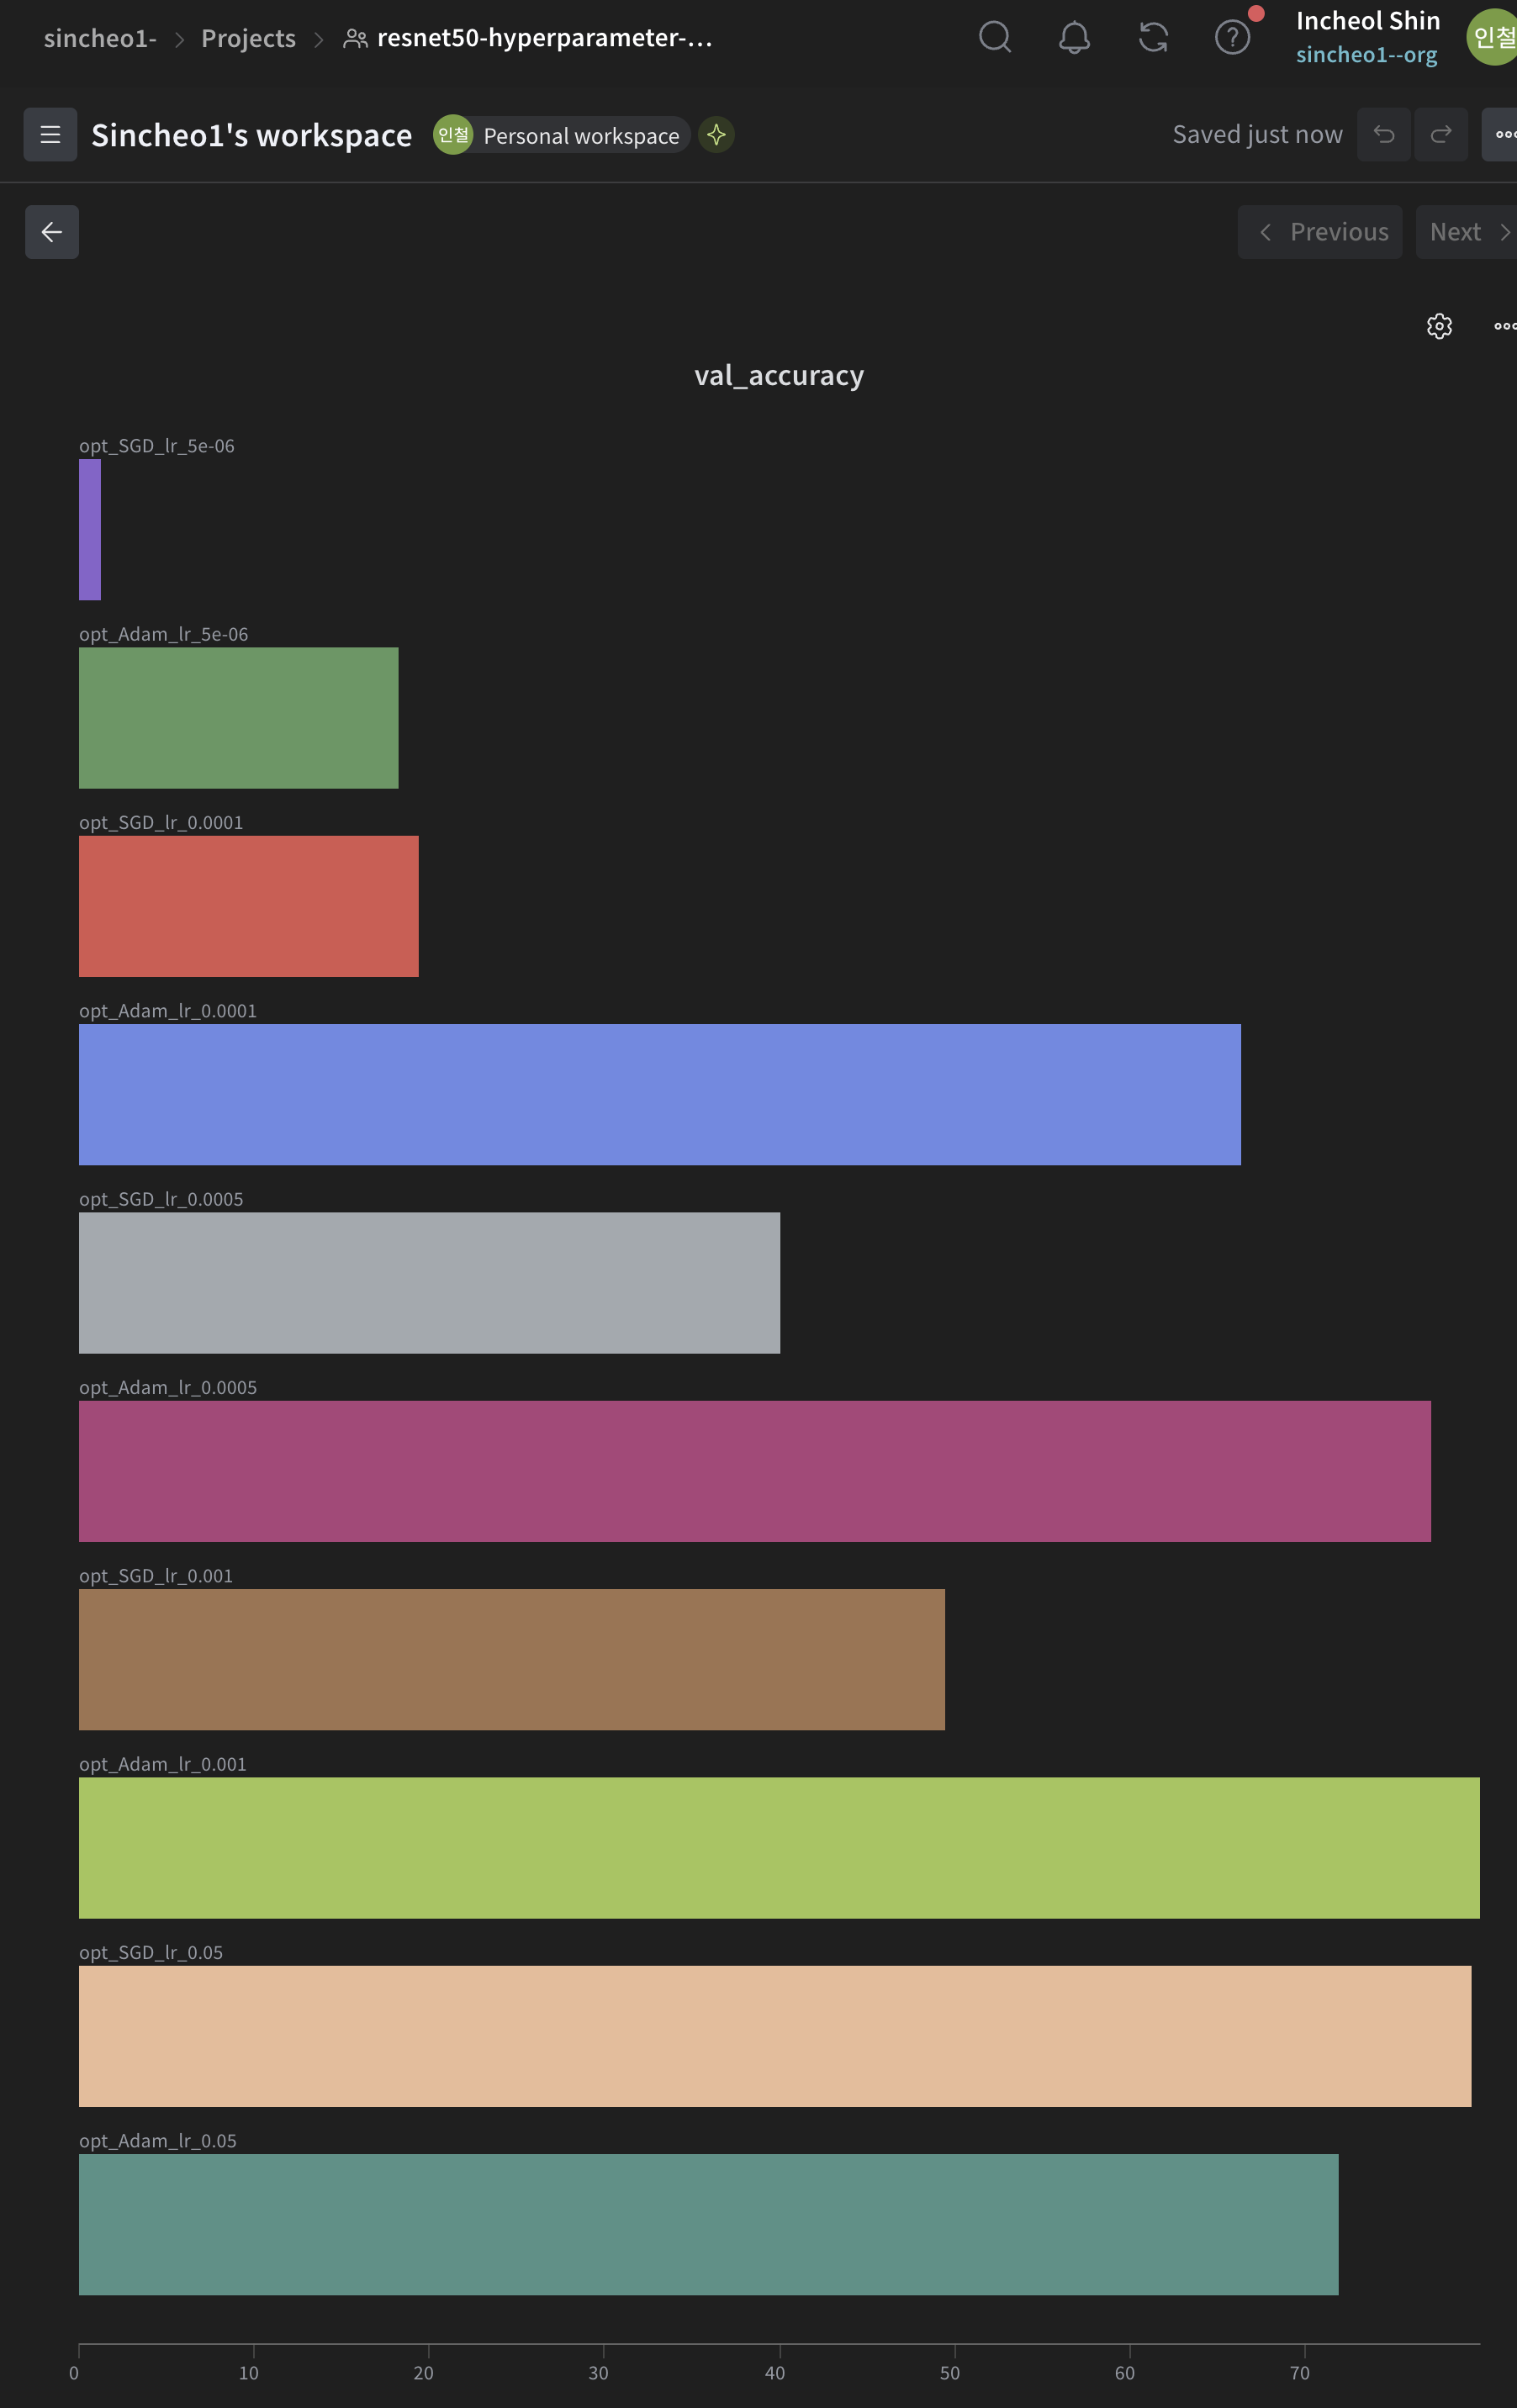

In [ ]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import wandb
import random # 랜덤 모듈 추가

wandb.login()

num_trials = 10 # grid srch는 조합만큼 실행하지만, 여기서는 우리가 정해줌

hp_range = {
    'lr_min' : -5,
    'lr_max' : -1,
    'optimizer': ['Adam', 'SGD']
}

def get_model(num_classes, device):
  weights = models.ResNet50_Weights.DEFAULT
  model = models.resnet50(weights = weights)

  # pre-trained freeze
  for param in model.parameters():
    param.requires_grad = False

  # head change
  num_ftrs = model.fc.in_features
  model.fc = nn.Linear(num_ftrs, num_classes)

  # 마지막 conv layer unfreeze
  for param in model.layer4.parameters():
    param.requires_grad = True

  return model.to(device)

def run_trial(lr, optimizer_name, device, train_loader, val_loader):
  print(f"실험 시작 (Random Search): LR={lr}, Opt={optimizer_name}")

  model = get_model(101, device)
  criterion = nn.CrossEntropyLoss()

  if optimizer_name == 'Adam':
    optimizer = optim.Adam([
        {'params' : model.layer4.parameters(), 'lr' : lr*5e-2},
        {'params' : model.fc.parameters(), 'lr' : lr}
    ])
  elif optimizer_name == 'SGD':
    optimizer = optim.SGD([
        {'params' : model.layer4.parameters(), 'lr' : lr*5e-2},
        {'params' : model.fc.parameters(), 'lr':lr}],
        momentum = 0.9
    )

  # training(3epochs)
  for epoch in range(3):
    print(f"Epoch : {epoch+1}/3 ing...")
    model.train()
    for i, (images, labels) in enumerate(train_loader):
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad() # 초기화
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      if (i+1)%500==0:
        print(f" Batch {i+1} / {len(train_loader)}")

  # validation (training이 끝나고 계산)
  model.eval()
  correct = 0
  total = 0
  print(".  Validation...")
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  acc = 100*correct / total
  print(f" Result : Validation Acc : {acc:.4f}%")
  return acc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 64

weights = models.ResNet50_Weights.DEFAULT
preprocess = weights.transforms()

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = preprocess

train_dataset = torchvision.datasets.Food101(root='./data', split='train', download=True, transform=train_transform)
val_dataset = torchvision.datasets.Food101(root='./data', split='test', download=True, transform=val_transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

wandb_project_name = "resnet50-hyperparameter-random-food101"

print(f"총 {num_trials}번의 Random Search 실험을 시작합니다.")

for i in range(num_trials):
  # ⭐️ 랜덤 파라미터 선택 (Sampling)
  lr = 10 ** random.uniform(hp_range['lr_min'], hp_range['lr_max'])
  opt_name = random.choice(hp_range['optimizer'])

  # W&B Run 시작
  run = wandb.init(
      project=wandb_project_name,
      name=f"trial_{i+1}_opt_{opt_name}_lr_{lr}",
      config={
          "learning_rate": lr,
          "optimizer": opt_name,
          "architecture": "ResNet50",
          "dataset": "Food-101",
          "search_method": "Random Search"
      },
      reinit=True
  )

  # 학습 및 평가 실행
  final_accuracy = run_trial(lr, opt_name, device, train_loader, val_loader)

  # 결과 기록
  wandb.log({"val_accuracy": final_accuracy})

  # 종료
  wandb.finish()

print("모든 Random Search 실험 종료")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


총 10번의 Random Search 실험을 시작합니다.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


실험 시작 (Random Search): LR=0.0006821904981382279, Opt=Adam
Epoch : 1/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
Epoch : 2/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
Epoch : 3/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
.  Validation...
 Result : Validation Acc : 78.8198%


val_accuracy,▁
val_accuracy,78.8198


...

실험 시작 (Random Search): LR=0.0015518859519259342, Opt=Adam
Epoch : 1/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
Epoch : 2/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
Epoch : 3/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
.  Validation...
 Result : Validation Acc : 80.7129%


val_accuracy,▁
val_accuracy,80.71287


실험 시작 (Random Search): LR=1.4366995650556934e-05, Opt=Adam
Epoch : 1/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
Epoch : 2/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
Epoch : 3/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
.  Validation...
 Result : Validation Acc : 40.0356%


val_accuracy,▁
val_accuracy,40.03564


실험 시작 (Random Search): LR=0.00022138336847285744, Opt=SGD
Epoch : 1/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
Epoch : 2/3 ing...
 Batch 500 / 1184
 Batch 1000 / 1184
Epoch : 3/3 ing...


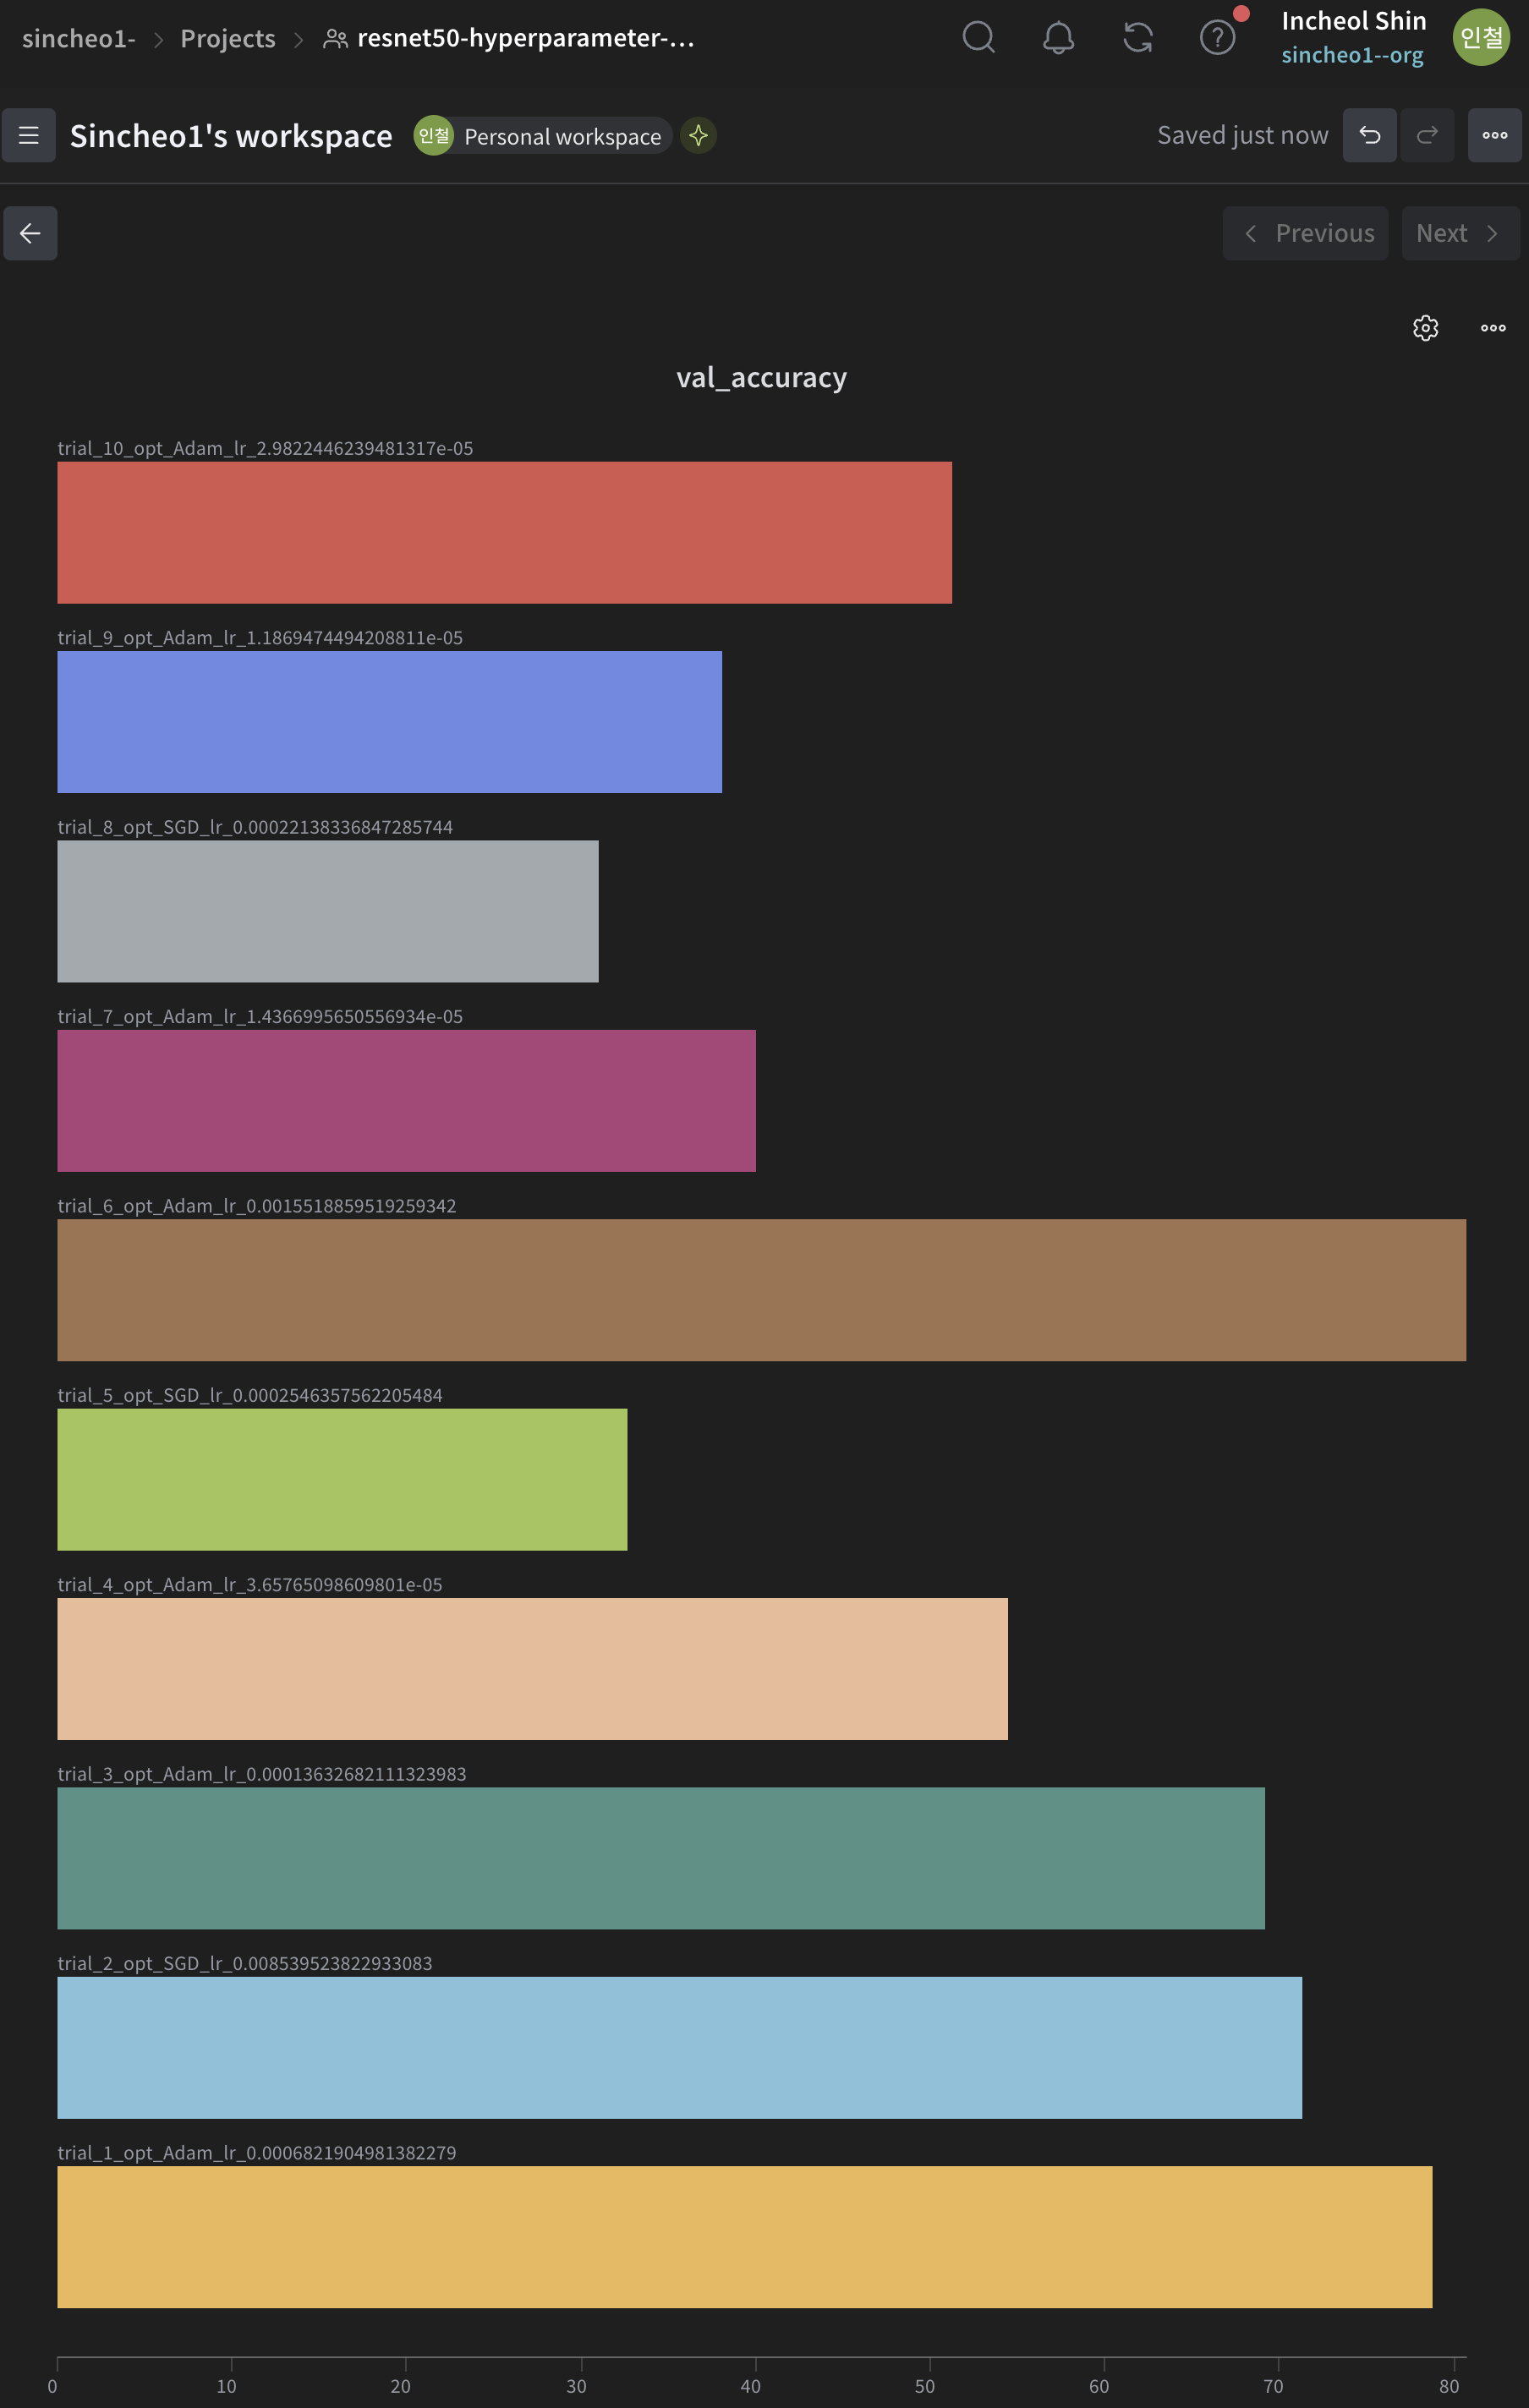